### Lineare Regression mit Keras nachbauen

#### 1) Daten laden

In [13]:
import pandas as pd
from math import ceil

pd.set_option('display.max_columns', 6)

data_url=r'https://raw.githubusercontent.com/rawe64/ai/main/ndx100.csv'
df = pd.read_csv(data_url)
df.head()

,m199,m99,m49,...,m3,m1,p5
0,-34.023668,-24.908597,-26.302555,...,-3.567182,0.328812,-5.638866
1,-45.493319,-34.786439,-31.315602,...,-10.180812,-5.099538,-6.134486
2,-42.415836,-36.541864,-34.279911,...,-4.975005,-0.211015,-6.591711
3,-53.283988,-36.786283,-40.070083,...,-9.990068,-4.432868,-6.060527
4,-40.239003,-34.040967,-29.901523,...,1.331406,5.718546,-9.906045


#### 2) x-/y-Daten selektieren und standardisieren

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[['age', 'bmi', 'children']].values
y = df[['charges']].values

scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y = scaler_y.fit_transform(y)

X.shape, y.shape

((1338, 3), (1338, 1))

#### 3) Keras-Modell aufbauen

In [ ]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(Dense(units=1, input_shape=(3,)))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

#### 4) Modell kompilieren
##### Variante 1:

In [ ]:
model.compile(loss='mse', optimizer='sgd')

##### Variante 2:

In [ ]:
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import SGD

mse = MeanSquaredError()
sgd = SGD(learning_rate=0.005)
model.compile(loss=mse, optimizer=sgd)

#### 5) Modell anlernen

In [ ]:
history = model.fit(X, y, epochs=5, batch_size=16)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.1411
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.1050
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9841
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9499
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8839


#### 6) Nach dem Anlernen

##### Gewichte abfragen:

In [ ]:
weights = model.get_layer(index=0).get_weights()
weights

[array([[0.30070218],
        [0.13829243],
        [0.04819427]], dtype=float32),
 array([-0.00106048], dtype=float32)]

##### Schätzungen für einen Beispieldatensatz erzeugen:

In [ ]:
X_pred = [[40., 20.1, 1.]]
X_pred = scaler_X.transform(X_pred)
y_pred = model.predict(X_pred)
y_pred = scaler_y.inverse_transform(y_pred)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


array([[10516.168]], dtype=float32)

#### 7) Evaluation

##### R-Quadrat:

In [ ]:
from sklearn.metrics import r2_score
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print('r2 = {:.3f}'.format(r2))

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
r2 = 0.119


#### 8) Anlernprozess graphisch darstellen

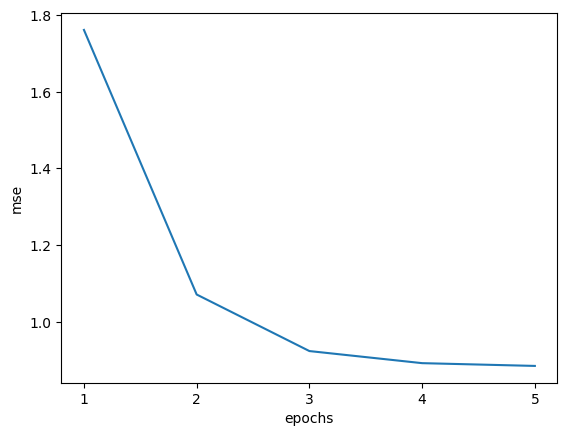

In [ ]:
import matplotlib.pyplot as plt

loss_mse = history.history['loss']
plt.xticks(range(1, len(loss_mse)+1))
plt.ylabel('mse')
plt.xlabel('epochs')
plt.plot(range(1, len(loss_mse)+1), loss_mse)